# 🔧 Notebook 2 — Preprocessing & Feature Engineering
---
**Objectif** : Nettoyer les données, séparer vente et location sur la base des données réelles, traiter les outliers et les valeurs manquantes, puis enrichir le dataset avec des features avancées.

**Stratégies appliquées :**
- Séparation vente/location basée sur les données textuelles (titre, description, colonne transaction)
- Filtrage sur un segment homogène (exclusion des biens industriels)
- Imputation contextuelle (médiane par ville × type de bien)
- 6 variables de distance géographique (mer, centre-ville, aéroport, parc, UCAD, VDN)
- 10 features binaires extraites du titre et de la description
- Target Encoding pour la ville (prix moyen par quartier)
- Transformation log(prix) comme variable cible

## Table des matières
1. Chargement
2. Nettoyage initial
3. Détection de la transaction depuis les données réelles
4. Filtrage homogène et outliers
5. Imputation des valeurs manquantes
6. Feature Engineering — distances géographiques
7. Feature Engineering — variables dérivées et texte
8. Target Encoding pour la ville
9. Diagnostic de qualité
10. Sauvegarde du dataset final


## 1. Chargement

In [2]:
import os, sys, django
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"]    = (13, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "immobilier_project.settings")
django.setup()

from django.db import connections
from IPython import get_ipython
ip = get_ipython()
if ip:
    ip.events.register("pre_run_cell", lambda info: connections.close_all())
connections.close_all()
print("Environnement Django pret.")


Environnement Django pret.


In [3]:
from properties.models import (
    CoinAfriqueProperty, ExpatDakarProperty,
    LogerDakarProperty, DakarVenteProperty, ImmoSenegalProperty
)

def load_source(model, source, extra_fields=None):
    base      = ["id", "price", "surface_area", "bedrooms", "bathrooms",
                 "city", "property_type", "statut", "adresse",
                 "title", "description"]
    available = [f.name for f in model._meta.get_fields()]
    fields    = [f for f in (base + (extra_fields or [])) if f in available]
    rows      = list(model.objects.values(*fields))
    df        = pd.DataFrame(rows)
    df["source"] = source
    return df

df_coin  = load_source(CoinAfriqueProperty, "coinafrique", ["latitude", "longitude"])
df_expat = load_source(ExpatDakarProperty,  "expat_dakar")
df_loger = load_source(LogerDakarProperty,  "loger_dakar")
df_dv    = load_source(DakarVenteProperty,  "dakarvente",  ["transaction"])
df_immo  = load_source(ImmoSenegalProperty, "immosenegal", ["transaction"])

for df_ in [df_expat, df_loger, df_coin]:
    if "transaction" not in df_.columns:
        df_["transaction"] = None
for df_ in [df_expat, df_loger, df_dv, df_immo]:
    if "latitude"  not in df_.columns: df_["latitude"]  = None
    if "longitude" not in df_.columns: df_["longitude"] = None

df_raw = pd.concat(
    [df_coin, df_expat, df_loger, df_dv, df_immo],
    ignore_index=True
)
print(f"Dataset total  : {len(df_raw):,} annonces")
print(f"  CoinAfrique  : {len(df_coin):,}")
print(f"  Expat-Dakar  : {len(df_expat):,}")
print(f"  Loger-Dakar  : {len(df_loger):,}")
print(f"  DakarVente   : {len(df_dv):,}")
print(f"  ImmoSenegal  : {len(df_immo):,}")


Dataset total  : 8,118 annonces
  CoinAfrique  : 4,062
  Expat-Dakar  : 285
  Loger-Dakar  : 1,828
  DakarVente   : 1,871
  ImmoSenegal  : 72


## 2. Nettoyage initial

In [4]:
df = df_raw.copy()
n0 = len(df)

df = df[df["price"].notna() & (df["price"] > 0)].copy()
print(f"Sans prix supprimes          : {n0 - len(df):,}")

n1 = len(df)
df = df.drop_duplicates(subset="id").copy()
print(f"Doublons supprimes           : {n1 - len(df):,}")

df["city"] = (df["city"].astype(str).str.strip()
              .str.split(",").str[0].str.strip().str.title()
              .replace({"Nan": np.nan, "None": np.nan, "": np.nan}))

df["property_type"] = (df["property_type"].astype(str).str.strip().str.title()
                       .replace({"Nan": np.nan, "None": np.nan, "": np.nan}))

df["title"]       = df.get("title",       pd.Series(dtype=str)).fillna("").astype(str).str.strip()
df["description"] = df.get("description", pd.Series(dtype=str)).fillna("").astype(str).str.strip()

print(f"Dataset apres nettoyage      : {len(df):,} annonces")


Sans prix supprimes          : 0
Doublons supprimes           : 0
Dataset apres nettoyage      : 8,118 annonces


## 3. Détection de la transaction depuis les données réelles

La séparation vente/location repose sur trois sources consultées dans l'ordre :
1. La colonne `transaction` explicite (DakarVente, ImmoSénégal)
2. Le titre de l'annonce
3. La description

Cette méthode est fiable car les annonces mentionnent systématiquement dans leur titre si le bien est à vendre ou à louer.


In [5]:
# Mots-cles de detection de la transaction
KW_LOCATION = ["louer", "location", "locat", "a louer", "meuble", "meublee"]
KW_VENTE    = ["vendre", "vente", "a vendre", "achat", "cession", "acquisition"]

def detect_transaction(row):
    """
    Detecte la nature de la transaction (vente ou location) depuis :
    1. La colonne transaction explicite si elle existe (DakarVente, ImmoSenegal)
    2. Le titre de l annonce
    3. La description
    Les accents sont retires pour eviter les problemes d encodage.
    """
    txn = str(row.get("transaction") or "").lower().strip()
    if txn in ("vente", "location"):
        return txn

    title = (str(row.get("title") or "")
             .lower()
             .replace("é", "e").replace("à", "a")
             .replace("é", "e").replace("ê", "e"))
    if any(k in title for k in KW_LOCATION): return "location"
    if any(k in title for k in KW_VENTE):    return "vente"

    desc = (str(row.get("description") or "")
            .lower()
            .replace("é", "e").replace("à", "a")
            .replace("é", "e").replace("ê", "e"))
    if any(k in desc for k in KW_LOCATION): return "location"
    if any(k in desc for k in KW_VENTE):    return "vente"

    return "inconnu"


In [6]:
df["transaction"] = df.apply(detect_transaction, axis=1)

print("REPARTITION PAR TRANSACTION :")
print(df["transaction"].value_counts().to_string())
print(f"Taux de classification : {(df['transaction'] != 'inconnu').mean()*100:.1f} %")

print("RÉPARTITION PAR SOURCE ET TRANSACTION :")
pivot = df.groupby(["source", "transaction"]).size().unstack(fill_value=0)
print(pivot.to_string())

# Exemples de non classes pour diagnostic
df_inconnu = df[df["transaction"] == "inconnu"]
if len(df_inconnu) > 0:
    print(f"EXEMPLES NON CLASSIFIES ({len(df_inconnu):,}) :")
    print(df_inconnu[["source", "title", "price"]].head(10).to_string())


REPARTITION PAR TRANSACTION :
transaction
location    5284
vente       2314
inconnu      520
Taux de classification : 93.6 %
RÉPARTITION PAR SOURCE ET TRANSACTION :
transaction  inconnu  location  vente
source                               
coinafrique      289      2876    897
dakarvente         9       821   1041
expat_dakar       35       181     69
immosenegal        0        14     58
loger_dakar      187      1392    249
EXEMPLES NON CLASSIFIES (520) :
          source           title     price
3    coinafrique    Terrain 1800  11000000
25   coinafrique       Terrain -   8500000
41   coinafrique       Terrain -  15000000
53   coinafrique       Terrain -  12500000
90   coinafrique  Appartement f4    250000
91   coinafrique        Studio à    250000
94   coinafrique   Terrain 150m²   3000000
110  coinafrique       Terrain -  20000000
113  coinafrique   Terrain 150m²  16500000
152  coinafrique     Terrain 150   9000000


In [8]:
# Separation des deux segments
df_location = df[df["transaction"] == "location"].copy()
df          = df[df["transaction"] == "vente"].copy()

print(f"Segment VENTE    : {len(df):,} annonces")
print(f"Segment LOCATION : {len(df_location):,} annonces")

df_location.to_csv("dataset_location_brut.csv", index=False)
print("Segment location sauvegarde -> dataset_location_brut.csv")

Segment VENTE    : 2,314 annonces
Segment LOCATION : 0 annonces
Segment location sauvegarde -> dataset_location_brut.csv


## 4. Filtrage homogène et outliers

In [9]:
# Exclusion des biens industriels et agricoles
EXCLUSIONS = ["ndustr", "agricol", "hectare", "entrep",
              "hangar", "usine", "ferme", "entrepot"]
mask = (df["property_type"].fillna("").str.lower().apply(
            lambda x: any(e in x for e in EXCLUSIONS)) |
        df["title"].str.lower().apply(
            lambda x: any(e in x for e in EXCLUSIONS)))
n_excl = mask.sum()
df     = df[~mask].copy()

# Regroupement des modalites rares
for col, seuil in [("property_type", 20), ("city", 10)]:
    rare    = df[col].value_counts()[df[col].value_counts() < seuil].index
    df[col] = df[col].replace(rare, "Autre")

print(f"Biens industriels exclus     : {n_excl:,}")
print(f"Dataset apres filtrage       : {len(df):,}")
print(f"Villes uniques               : {df['city'].nunique()}")
print(f"Types de biens               : {df['property_type'].nunique()}")
print()
print("DISTRIBUTION DU PRIX AVANT TRAITEMENT OUTLIERS :")
print(df["price"].describe().apply(lambda x: f"{x:,.0f}"))
cv = df["price"].std() / df["price"].mean()
print(f"CV : {cv:.2f} (objectif < 1.5 pour un segment homogene)")


Biens industriels exclus     : 322
Dataset apres filtrage       : 1,992
Villes uniques               : 42
Types de biens               : 21

DISTRIBUTION DU PRIX AVANT TRAITEMENT OUTLIERS :
count            1,992
mean       111,495,947
std        207,131,287
min                  2
25%          9,000,000
50%         40,000,000
75%        120,000,000
max      2,147,483,647
Name: price, dtype: str
CV : 1.86 (objectif < 1.5 pour un segment homogene)


Variable               Seuil min        Seuil max      Outliers
--------------------------------------------------------------
price                  1,000,000    2,000,000,000         122 (6.1 %)
surface_area                  10            3,000         182 (9.1 %)
bedrooms                       1               20           2 (0.1 %)
bathrooms                      1               15           4 (0.2 %)
Dataset apres outliers       : 1,870
CV prix apres                : 1.73


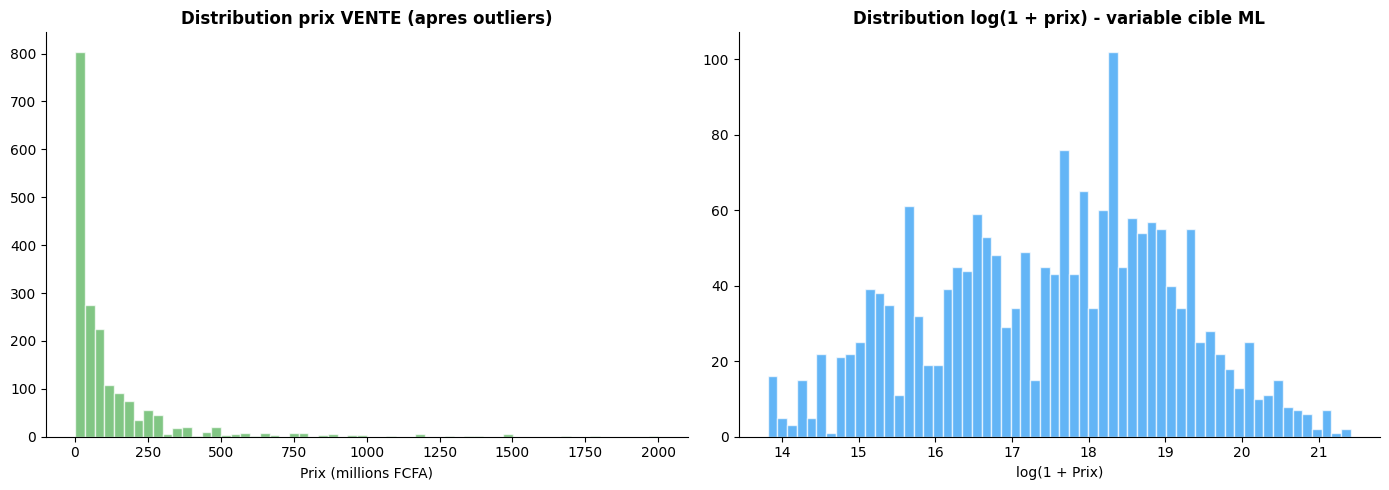

In [10]:
SEUILS = {
    "price":        (1_000_000,  2_000_000_000),
    "surface_area": (10,         3_000),
    "bedrooms":     (1,          20),
    "bathrooms":    (1,          15),
}
print(f"{'Variable':<15}  {'Seuil min':>15}  {'Seuil max':>15}  {'Outliers':>12}")
print("-" * 62)
for col, (low, high) in SEUILS.items():
    mask   = df[col].notna() & ((df[col] < low) | (df[col] > high))
    n      = mask.sum()
    df.loc[mask, col] = np.nan
    print(f"{col:<15}  {low:>15,.0f}  {high:>15,.0f}  {n:>10,} ({n/len(df)*100:.1f} %)")

df = df.dropna(subset=["price"]).copy()
print(f"Dataset apres outliers       : {len(df):,}")
cv2 = df["price"].std() / df["price"].mean()
print(f"CV prix apres                : {cv2:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["price"] / 1e6, bins=60, color="#4CAF50", alpha=0.7, edgecolor="white")
axes[0].set_title("Distribution prix VENTE (apres outliers)", fontweight="bold")
axes[0].set_xlabel("Prix (millions FCFA)")
axes[1].hist(np.log1p(df["price"]), bins=60, color="#2196F3", alpha=0.7, edgecolor="white")
axes[1].set_title("Distribution log(1 + prix) - variable cible ML", fontweight="bold")
axes[1].set_xlabel("log(1 + Prix)")
plt.tight_layout()
plt.savefig("../outputs/fig_09_prix_filtre.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Imputation des valeurs manquantes

In [11]:
print("TAUX DE VALEURS MANQUANTES AVANT IMPUTATION :")
for col in ["surface_area", "bedrooms", "bathrooms", "city", "property_type"]:
    n = df[col].isna().sum()
    print(f"  {col:<15} : {n:,} ({n/len(df)*100:.1f} %)")

# surface_area — mediane par (city x property_type) -> property_type -> global
df["surface_area"] = (df["surface_area"]
    .fillna(df.groupby(["city","property_type"])["surface_area"].transform("median"))
    .fillna(df.groupby("property_type")["surface_area"].transform("median"))
    .fillna(df["surface_area"].median()))

for col in ["bedrooms", "bathrooms"]:
    df[col] = (df[col]
        .fillna(df.groupby("property_type")[col].transform("median"))
        .fillna(df[col].median()))

df["city"]          = df["city"].fillna(df["city"].mode()[0])
df["property_type"] = df["property_type"].fillna(df["property_type"].mode()[0])

print("TAUX DE VALEURS MANQUANTES APRES IMPUTATION :")
for col in ["surface_area", "bedrooms", "bathrooms", "city", "property_type"]:
    n = df[col].isna().sum()
    print(f"  {col:<15} : {n}")


TAUX DE VALEURS MANQUANTES AVANT IMPUTATION :
  surface_area    : 325 (17.4 %)
  bedrooms        : 1,127 (60.3 %)
  bathrooms       : 1,206 (64.5 %)
  city            : 0 (0.0 %)
  property_type   : 0 (0.0 %)
TAUX DE VALEURS MANQUANTES APRES IMPUTATION :
  surface_area    : 0
  bedrooms        : 0
  bathrooms       : 0
  city            : 0
  property_type   : 0


## 6. Feature Engineering — Distances géographiques

In [12]:
from math import radians, sin, cos, sqrt, atan2

POI = {
    "mer":       [(14.7457, -17.5197), (14.7247, -17.5025)],
    "centre":    (14.6928, -17.4467),
    "aeroport":  (14.7397, -17.4902),
    "parc":      (14.7122, -17.4488),
    "ucad":      (14.6925, -17.4636),
    "vdn":       (14.7200, -17.4600),
}
CITY_COORDS = {
    "Almadies":      (14.7453, -17.5109), "Ngor":         (14.7490, -17.5140),
    "Ouakam":        (14.7237, -17.4942), "Yoff":         (14.7575, -17.4900),
    "Mermoz":        (14.7100, -17.4750), "Fann":         (14.6961, -17.4603),
    "Plateau":       (14.6928, -17.4467), "Pikine":       (14.7546, -17.3947),
    "Guediawaye":    (14.7780, -17.3930), "Rufisque":     (14.7156, -17.2736),
    "Grand Yoff":    (14.7500, -17.4600), "Sacre Coeur":  (14.7150, -17.4650),
    "Liberte":       (14.7089, -17.4517), "Hlm":          (14.7089, -17.4517),
    "Sicap":         (14.7050, -17.4600), "Vdn":          (14.7200, -17.4600),
    "Hann Maristes": (14.7300, -17.4200), "Thies":        (14.7910, -16.9260),
    "Mbour":         (14.3641, -16.9658), "Dakar":        (14.6928, -17.4467),
    "Autre":         (14.6928, -17.4467),
}

def hav(la1, lo1, la2, lo2):
    R = 6371
    la1, lo1, la2, lo2 = map(radians, [la1, lo1, la2, lo2])
    a = sin((la2-la1)/2)**2 + cos(la1)*cos(la2)*sin((lo2-lo1)/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def get_coords(row):
    try:
        lat = float(row.get("latitude")  or 0)
        lon = float(row.get("longitude") or 0)
        if 12 < lat < 17 and -18 < lon < -14:
            return lat, lon
    except (TypeError, ValueError):
        pass
    return CITY_COORDS.get(str(row.get("city") or "Dakar"), CITY_COORDS["Dakar"])

coords       = df.apply(get_coords, axis=1)
df["_lat"]   = [c[0] for c in coords]
df["_lon"]   = [c[1] for c in coords]

df["dist_mer"]      = df.apply(lambda r: min(hav(r["_lat"], r["_lon"], *p) for p in POI["mer"]),    axis=1)
df["dist_centre"]   = df.apply(lambda r: hav(r["_lat"], r["_lon"], *POI["centre"]),   axis=1)
df["dist_aeroport"] = df.apply(lambda r: hav(r["_lat"], r["_lon"], *POI["aeroport"]), axis=1)
df["dist_parc"]     = df.apply(lambda r: hav(r["_lat"], r["_lon"], *POI["parc"]),     axis=1)
df["dist_ucad"]     = df.apply(lambda r: hav(r["_lat"], r["_lon"], *POI["ucad"]),     axis=1)
df["dist_vdn"]      = df.apply(lambda r: hav(r["_lat"], r["_lon"], *POI["vdn"]),      axis=1)
df.drop(columns=["_lat", "_lon"], inplace=True)

geo_cols = ["dist_mer", "dist_centre", "dist_aeroport", "dist_parc", "dist_ucad", "dist_vdn"]
print("VARIABLES DE DISTANCE CREEES (km)")
print(df[geo_cols].describe().round(2).to_string())
print("Correlations distances -> prix :")
for c in geo_cols:
    r    = df[["price", c]].dropna().corr().iloc[0, 1]
    sens = "(proche = cher)" if r < 0 else "(eloigne = cher)"
    print(f"  {c:<20} : {r:>7.4f}  {sens}")


VARIABLES DE DISTANCE CREEES (km)
       dist_mer  dist_centre  dist_aeroport  dist_parc  dist_ucad  dist_vdn
count  1,870.00     1,870.00       1,870.00   1,870.00   1,870.00  1,870.00
mean      16.67        12.96          16.57      13.66      13.89     14.14
std       27.60        26.75          27.35      26.66      26.92     26.94
min        0.10         0.00           0.83       1.39       0.54      0.41
25%        4.37         0.00           4.37       2.17       1.82      3.35
50%        6.97         3.48           7.01       2.17       2.72      3.35
75%        7.74        10.22           7.01       8.79       8.82      7.51
max      275.00       268.99         275.81     271.00     269.84    272.33
Correlations distances -> prix :
  dist_mer             : -0.1150  (proche = cher)
  dist_centre          : -0.0823  (proche = cher)
  dist_aeroport        : -0.1100  (proche = cher)
  dist_parc            : -0.0899  (proche = cher)
  dist_ucad            : -0.0916  (proche = cher)

## 7. Feature Engineering — Variables dérivées et texte

In [13]:
PREMIUM = ["Almadies", "Ngor", "Ouakam", "Mermoz", "Fann", "Plateau",
           "Corniche", "Mamelles", "Liberte", "Point E", "Vdn"]

df["rooms_total"]      = df["bedrooms"].fillna(0) + df["bathrooms"].fillna(0)
df["surface_per_room"] = df.apply(
    lambda r: r["surface_area"] / r["bedrooms"]
    if pd.notna(r.get("surface_area")) and pd.notna(r.get("bedrooms")) and r["bedrooms"] > 0
    else np.nan, axis=1).fillna(df["surface_area"])
df["is_premium"]       = df["city"].apply(lambda c: int(str(c) in PREMIUM))
df["log_surface"]      = np.log1p(df["surface_area"])
df["log_dist_mer"]     = np.log1p(df["dist_mer"])
df["bath_bed_ratio"]   = df.apply(
    lambda r: r["bathrooms"] / r["bedrooms"]
    if pd.notna(r.get("bedrooms")) and r["bedrooms"] > 0 else 0, axis=1)

# Extraction du nombre de chambres depuis le titre quand bedrooms est absent
import re as _re
RE_FN = _re.compile(r"[FfTt](\d)")
RE_CH = _re.compile(r"(\d+)\s*chambre", _re.IGNORECASE)

def extract_bedrooms(row):
    if pd.notna(row.get("bedrooms")) and row["bedrooms"] > 0:
        return row["bedrooms"]
    txt = str(row.get("title", "")) + " " + str(row.get("description", ""))
    m   = RE_FN.search(txt) or RE_CH.search(txt)
    return int(m.group(1)) if m else row.get("bedrooms")

df["bedrooms"] = df.apply(extract_bedrooms, axis=1)

# Features binaires depuis le titre et la description
text_col = (df["title"] + " " + df["description"]).str.lower()
TEXT_FEATURES = {
    "has_piscine":     r"piscine",
    "has_standing":    r"standing|luxe|prestige",
    "has_meuble":      r"meuble|equipe",
    "has_parking":     r"parking|garage",
    "has_ascenseur":   r"ascenseur",
    "has_gardiennage": r"gardiennage|securise|gardien",
    "has_balcon":      r"balcon|terrasse",
    "has_vue_mer":     r"vue mer|bord de mer|face mer",
    "has_groupe_elec": r"groupe.lectrog.ne|generatrice",
    "has_climatise":   r"climatise|clim",
}
print("FEATURES TEXTE CREEES :")
for feat, pattern in TEXT_FEATURES.items():
    df[feat] = text_col.str.contains(pattern, na=False, regex=True).astype(int)
    n        = df[feat].sum()
    print(f"  {feat:<22} : {n:,} ({n/len(df)*100:.1f} %)")


FEATURES TEXTE CREEES :
  has_piscine            : 92 (4.9 %)
  has_standing           : 63 (3.4 %)
  has_meuble             : 53 (2.8 %)
  has_parking            : 141 (7.5 %)
  has_ascenseur          : 48 (2.6 %)
  has_gardiennage        : 51 (2.7 %)
  has_balcon             : 128 (6.8 %)
  has_vue_mer            : 11 (0.6 %)
  has_groupe_elec        : 0 (0.0 %)
  has_climatise          : 23 (1.2 %)


## 8. Target Encoding pour la ville

CORRELATIONS AVEC LE PRIX :
  city_mean_price  : 0.4157  (Target Encoding)
  surface_area     : 0.3115  (reference)

Le Target Encoding encode chaque ville par son prix moyen.
C'est la feature la plus puissante pour capturer l'effet localisation.


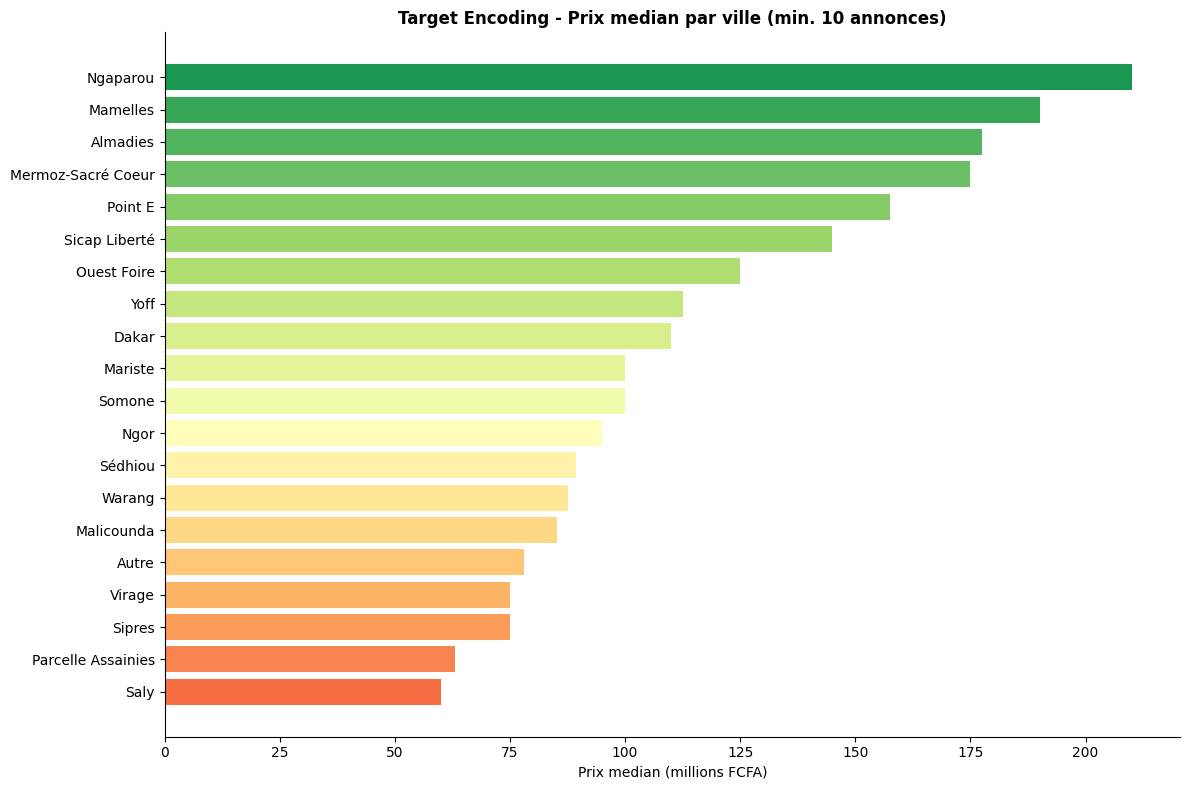

In [14]:
city_stats = df.groupby("city")["price"].agg(
    city_mean_price   = "mean",
    city_median_price = "median",
    city_count        = "count"
).reset_index()

df = df.merge(city_stats, on="city", how="left")

r_mean  = df[["price", "city_mean_price"]].corr().iloc[0, 1]
r_surf  = df[["price", "surface_area"]].corr().iloc[0, 1]

print("CORRELATIONS AVEC LE PRIX :")
print(f"  city_mean_price  : {r_mean:.4f}  (Target Encoding)")
print(f"  surface_area     : {r_surf:.4f}  (reference)")
print()
print("Le Target Encoding encode chaque ville par son prix moyen.")
print("C'est la feature la plus puissante pour capturer l'effet localisation.")

top20 = (city_stats[city_stats["city_count"] >= 10]
         .sort_values("city_median_price", ascending=True).tail(20))

fig, ax = plt.subplots(figsize=(12, 8))
colors  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top20)))
ax.barh(top20["city"], top20["city_median_price"] / 1e6, color=colors)
ax.set_xlabel("Prix median (millions FCFA)")
ax.set_title("Target Encoding - Prix median par ville (min. 10 annonces)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/fig_10_target_encoding.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Diagnostic de qualité

TOP CORRELATIONS AVEC LE PRIX :
---------------------------------------------
  city_mean_price           :  0.4157  +████████████████
  bathrooms                 :  0.3389  +█████████████
  rooms_total               :  0.3136  +████████████
  surface_area              :  0.3115  +████████████
  log_surface               :  0.3038  +████████████
  has_piscine               :  0.2814  +███████████
  bedrooms                  :  0.2514  +██████████
  has_parking               :  0.1935  +███████
  has_standing              :  0.1927  +███████
  is_premium                :  0.1422  +█████
  surface_per_room          :  0.1373  +█████
  dist_mer                  : -0.1150  -████
  has_vue_mer               :  0.0899  +███
  dist_centre               : -0.0823  -███


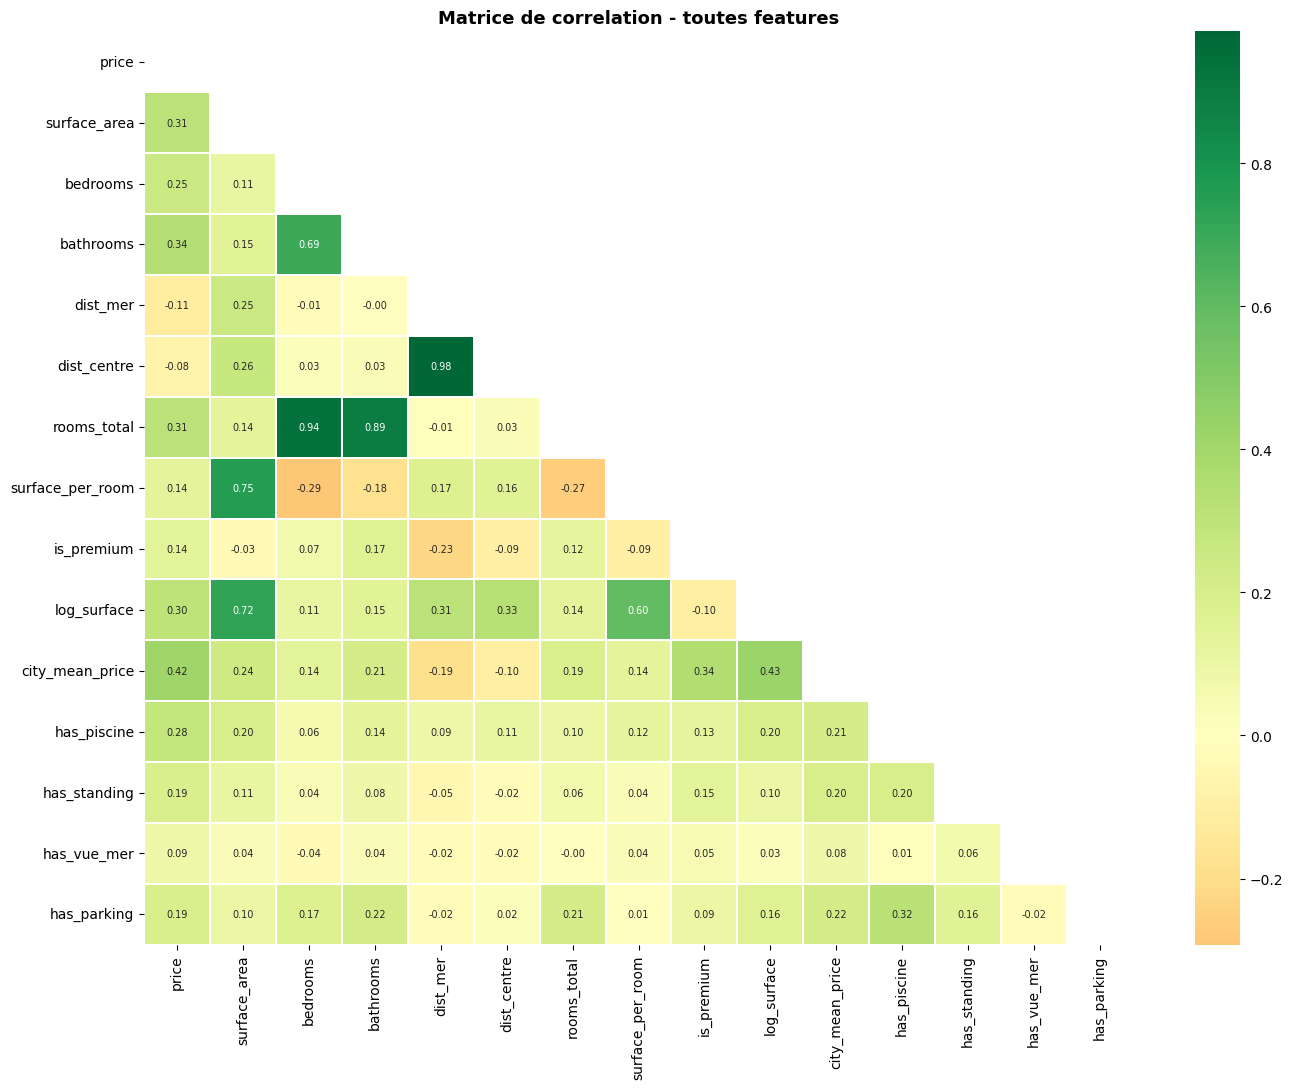

In [15]:
num_cols = ["price", "surface_area", "bedrooms", "bathrooms",
           "dist_mer", "dist_centre", "rooms_total", "surface_per_room",
           "is_premium", "log_surface", "city_mean_price",
           "has_piscine", "has_standing", "has_vue_mer", "has_parking"]

corr_price = (df[num_cols].corr()["price"]
              .drop("price")
              .sort_values(key=abs, ascending=False))

print("TOP CORRELATIONS AVEC LE PRIX :")
print("-" * 45)
for feat, val in corr_price.items():
    bar  = chr(9608) * int(abs(val) * 40)
    sens = "+" if val > 0 else "-"
    print(f"  {feat:<25} : {val:>7.4f}  {sens}{bar}")

fig, ax = plt.subplots(figsize=(14, 11))
corr    = df[num_cols].corr()
mask    = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, mask=mask,
            annot_kws={"size": 7}, linewidths=0.3)
ax.set_title("Matrice de correlation - toutes features", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/fig_11_corr_complete.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Sauvegarde du dataset final

In [16]:
import json

NUMERIC_FEATURES = [
    "surface_area", "bedrooms", "bathrooms",
    "dist_mer", "dist_centre", "dist_aeroport", "dist_parc", "dist_ucad", "dist_vdn",
    "rooms_total", "is_premium", "surface_per_room",
    "log_surface", "log_dist_mer", "bath_bed_ratio",
    "city_mean_price", "city_median_price", "city_count",
    "has_piscine", "has_standing", "has_meuble", "has_parking",
    "has_ascenseur", "has_gardiennage", "has_balcon", "has_vue_mer",
    "has_groupe_elec", "has_climatise",
]
CATEGORICAL_FEATURES = ["property_type", "source"]
TARGET    = "price"
LOG_TARGET = "log_price"

df["log_price"] = np.log1p(df["price"])

cols_final = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, LOG_TARGET]
df_final   = df[[c for c in cols_final if c in df.columns]].copy()
df_final   = df_final.dropna(subset=[TARGET])

print(f"Dataset final : {df_final.shape[0]:,} lignes x {df_final.shape[1]} colonnes")
print(f"Completude    : {df_final.notna().mean().mean() * 100:.1f} %")

missing = df_final.isnull().sum()
if missing.sum() > 0:
    print("Valeurs manquantes restantes :")
    print(missing[missing > 0].to_string())
else:
    print("Aucune valeur manquante ✅")

df_final.to_csv("dataset_final.csv", index=False)
config = {
    "NUMERIC_FEATURES":     NUMERIC_FEATURES,
    "CATEGORICAL_FEATURES": CATEGORICAL_FEATURES,
    "TARGET":               TARGET,
    "LOG_TARGET":           LOG_TARGET,
}
with open("features_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Dataset sauvegarde -> dataset_final.csv")
print("Config sauvegardee  -> features_config.json")
print(f"Recapitulatif :")
print(f"  Features numeriques    : {len(NUMERIC_FEATURES)}")
print(f"  Features categorielles : {len(CATEGORICAL_FEATURES)}")
print(f"  Total                  : {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)}")
df_final.describe().T


Dataset final : 1,870 lignes x 32 colonnes
Completude    : 100.0 %
Aucune valeur manquante ✅
Dataset sauvegarde -> dataset_final.csv
Config sauvegardee  -> features_config.json
Recapitulatif :
  Features numeriques    : 28
  Features categorielles : 2
  Total                  : 30


,count,mean,std,min,25%,50%,75%,max
surface_area,"1,870.00",213.61,262.96,10.00,61.00,150.00,295.00,"2,860.00"
bedrooms,"1,870.00",4.25,1.78,1.00,4.00,4.00,5.00,20.00
dist_mer,"1,870.00",16.67,27.60,0.10,4.37,6.97,7.74,275.00
dist_centre,"1,870.00",12.96,26.75,0.00,0.00,3.48,10.22,268.99
dist_aeroport,"1,870.00",16.57,27.35,0.83,4.37,7.01,7.01,275.81
dist_parc,"1,870.00",13.66,26.66,1.39,2.17,2.17,8.79,271.00
dist_ucad,"1,870.00",13.89,26.92,0.54,1.82,2.72,8.82,269.84
dist_vdn,"1,870.00",14.14,26.94,0.41,3.35,3.35,7.51,272.33
is_premium,"1,870.00",0.14,0.35,0.00,0.00,0.00,0.00,1.00
surface_per_room,"1,870.00",60.80,85.55,1.18,12.20,37.50,75.00,800.00
